Text to image Generation using staable Duffsion and Diffusers


In [1]:
! pip install diffusers transformers accelerate

In [2]:
from diffusers import StableDiffusionXLPipeline
import torch
import matplotlib.pyplot as plt
import gradio as gr

In [3]:
! pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [11]:
model_id1="dreamlike-art/dreamlike-diffusion-1.0"
model_id2="stabilityai/stable-diffusion-xl-base-1.0"

pipe=StableDiffusionPipeline.from_pretrained(model_id1,torch_dtype=torch.float16,use_auth_token=True)
pipe=pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Keyword arguments {'use_auth_token': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [12]:
prompt="""A girl is playing with gun with a left hand
and other main fer"""

In [13]:
image=pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

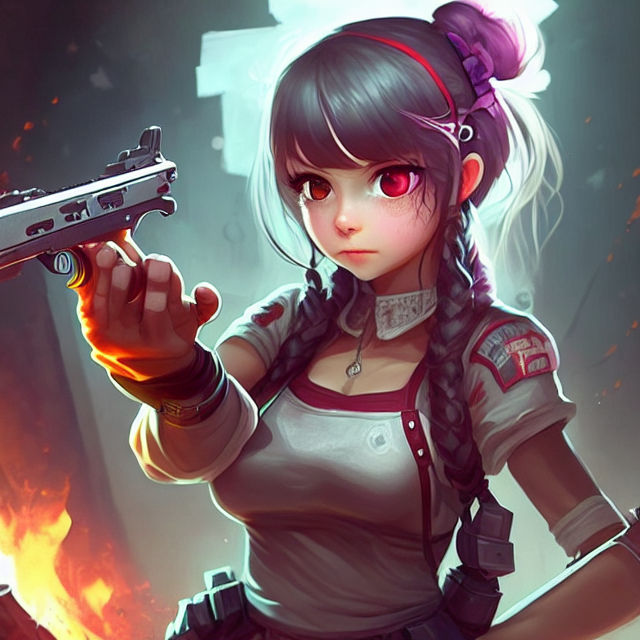

In [14]:
image

[PROMPT] A girl is playing with gun with a left hand
and other main fer


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

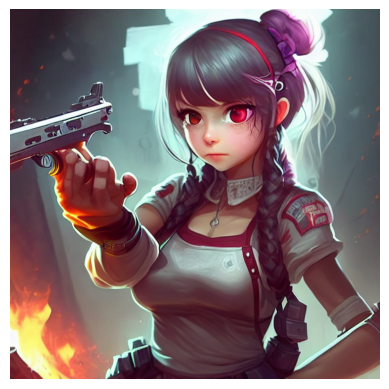

In [15]:
print("[PROMPT]",prompt)
plt.imshow(image)
plt.axis("off")

In [16]:
prompt2="""A girl on chair and she is reading the book"""
image=pipe(prompt2).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

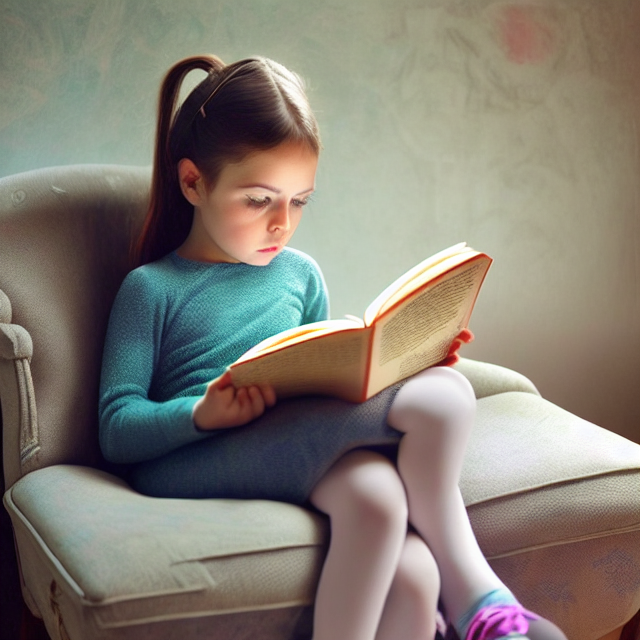

In [17]:
image

[PROMPT] A girl on chair and she is reading the book


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

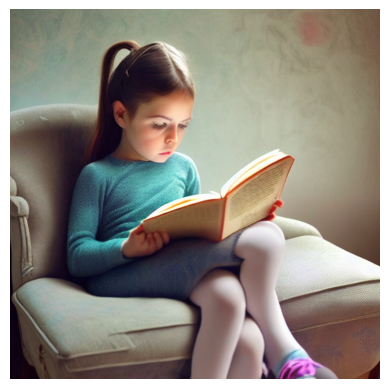

In [18]:
print("[PROMPT]",prompt2)
plt.imshow(image)
plt.axis("off")

In [28]:
def generate_image(pip,prompt,params):
  img=pip(prompt,**params).images
  num_images=len(img)
  if num_images>1:
    fig, ax=plt.subplots(nrows=1,ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i])
      ax[i].axis("off")
  else:
    flg=plt.figure()
    plt.imshow(img[0])
    plt.axis("off")
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [22]:
prompt="A man riding the bike"
params={}

  0%|          | 0/50 [00:00<?, ?it/s]

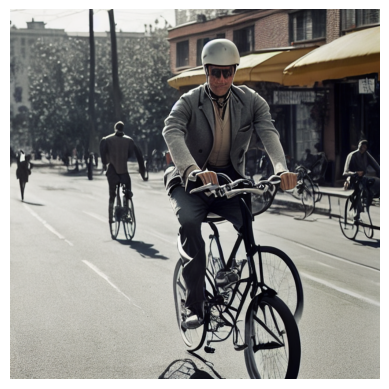

In [23]:
generate_image(pipe,prompt,params)

  0%|          | 0/50 [00:00<?, ?it/s]

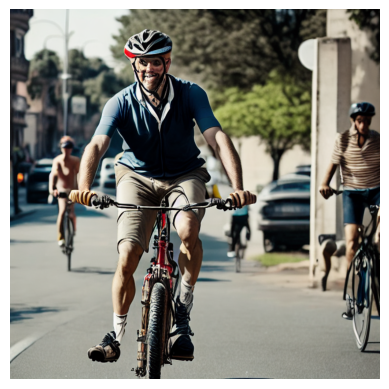

In [24]:
params={'num_inference_step':100}
generate_image(pipe,prompt,params)

  0%|          | 0/50 [00:00<?, ?it/s]

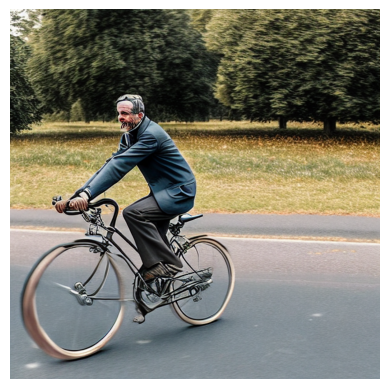

In [25]:
parms={'num_inference_steps':100, 'width':513,'height':int(1.5*630)}
generate_image(pipe,prompt,params)

  0%|          | 0/100 [00:00<?, ?it/s]

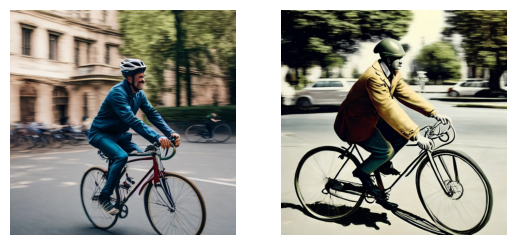

In [29]:
params={'num_inference_steps': 100, 'num_images_per_prompt': 2}
generate_image(pipe,prompt,params)

  0%|          | 0/100 [00:00<?, ?it/s]

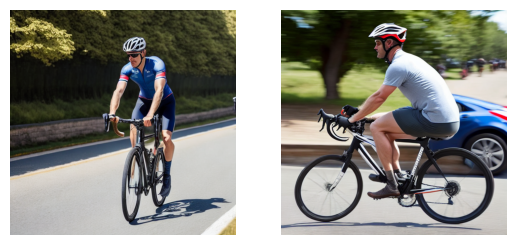

In [30]:
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2, 'negative_prompt': 'ugly, distorted,  low quality'}
generate_image(pipe,prompt,params)